In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
customer_data = pd.read_csv("customer_data_with_basket_behavior.csv")
customer_data.head()

,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,purchased_quantity,return_rate,return_value,net_revenue,net_to_gross_ratio,churn_class,avg_basket_quantity,avg_unique_items_per_basket,avg_basket_monetary_value,buyer_type
0,0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,...,70,0.242857,424.60,-51.74,-0.138765,churned,6.363636,3.0,33.896364,retail_buyer
1,1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,...,828,0.000000,0.00,1323.32,1.000000,active,414.000000,35.5,661.660000,retail_buyer
2,2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,...,373,0.000000,0.00,222.16,1.000000,one_off_buyer,373.000000,20.0,222.160000,retail_buyer
3,3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,...,993,0.005035,24.15,2646.99,0.990959,active,331.000000,34.0,890.380000,retail_buyer
4,4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,...,261,0.000000,0.00,300.93,1.000000,one_off_buyer,261.000000,21.0,300.930000,retail_buyer


In [3]:
customer_data.shape

(4312, 22)

In [4]:
customer_data = customer_data[customer_data["Customer ID"].notna()]

## Customer Value Segmentation with Basket Features (K-means Clustering)


To enhance customer value segmentation, I incorporated basket behavioral features (**'avg_basket_quantity', 'avg_unique_items_per_basket', and 'avg_basket_monetary_value'**) and used clustering algorithms to identify more nuanced value tiers (e.g., 'premium bulk buyer', 'diverse mid-tier shopper', 'low-value infrequent').


In [5]:
# selecting relevant features for clustering analysis
selected_clustering_features = [
    'gross_revenue',
    'avg_basket_quantity',
    'avg_unique_items_per_basket',
    'avg_basket_monetary_value'
]

customer_features_for_clustering = customer_data[selected_clustering_features].copy()

print("Customer features selected for clustering:")
display(customer_features_for_clustering.head())

Customer features selected for clustering:


,gross_revenue,avg_basket_quantity,avg_unique_items_per_basket,avg_basket_monetary_value
0,372.86,6.363636,3.0,33.896364
1,1323.32,414.000000,35.5,661.660000
2,222.16,373.000000,20.0,222.160000
3,2671.14,331.000000,34.0,890.380000
4,300.93,261.000000,21.0,300.930000


## Determine the optimal number of clusters using the Elbow Method



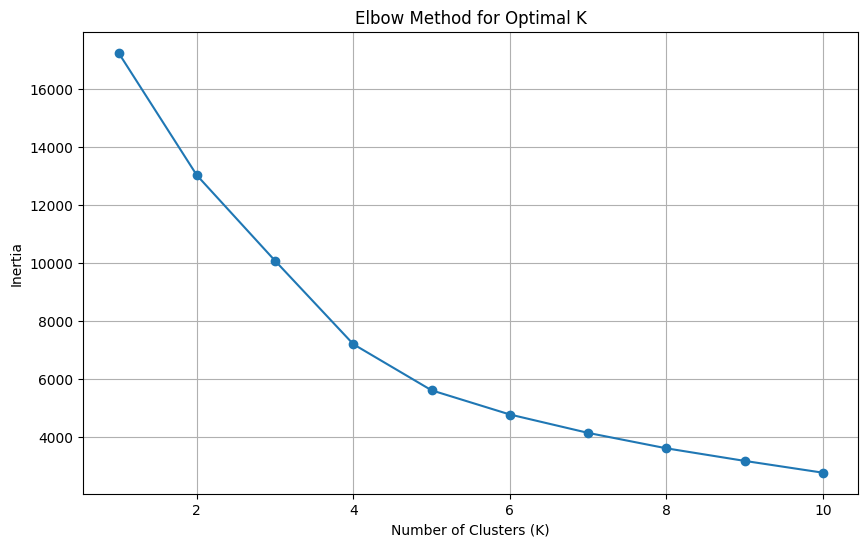

Elbow method plot generated to identify the optimal number of clusters.


In [6]:
# Determine the optimal number of clusters using the Elbow Method

# scaling the features before applying KMeans
scaler = StandardScaler()

# Initialize an empty list to store the inertia values
inertia = []

# Iterate through a range of possible cluster numbers (e.g., from 1 to 10)
for n_clusters in range(1, 11):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=n_clusters, random_state=42, n_init=10))
    ])
    
    pipeline.fit(customer_features_for_clustering)
    kmeans = pipeline.named_steps['kmeans']
    inertia.append(kmeans.inertia_)

# Plot the inertia values against the number of clusters
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

print("Elbow method plot generated to identify the optimal number of clusters.")

### Summary on Number of Clusters

Based on the elbow plot, I chose 4 as the optimal number of clusters, as this is where the rate of decrease in inertia slows down. I then ed K-Means clustering with this optimal K and assigned the resulting cluster labels to a new 'value_segment' column in customer data.



## Clustering Pipeline

In [7]:
optimal_clusters = 4

pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters= optimal_clusters, random_state=42, n_init=10))
    ])
    

pipeline.fit(customer_features_for_clustering)

customer_data['value_segment'] = pipeline.predict(customer_features_for_clustering)

print(f"K-Means clustering performed with {optimal_clusters} clusters.")
print("First few rows of customer_data with the new 'value_segment' column:")
display(customer_data.head())

K-Means clustering performed with 4 clusters.
First few rows of customer_data with the new 'value_segment' column:


,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,return_rate,return_value,net_revenue,net_to_gross_ratio,churn_class,avg_basket_quantity,avg_unique_items_per_basket,avg_basket_monetary_value,buyer_type,value_segment
0,0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,...,0.242857,424.60,-51.74,-0.138765,churned,6.363636,3.0,33.896364,retail_buyer,2
1,1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,...,0.000000,0.00,1323.32,1.000000,active,414.000000,35.5,661.660000,retail_buyer,0
2,2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,...,0.000000,0.00,222.16,1.000000,one_off_buyer,373.000000,20.0,222.160000,retail_buyer,2
3,3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,...,0.005035,24.15,2646.99,0.990959,active,331.000000,34.0,890.380000,retail_buyer,0
4,4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,...,0.000000,0.00,300.93,1.000000,one_off_buyer,261.000000,21.0,300.930000,retail_buyer,2


In [8]:
# Describe the characteristics of each value segment (cluster)
value_segment_characteristics = customer_data.groupby('value_segment')[selected_clustering_features].describe()

print("Characteristics of K-Means Value Segments:")
display(value_segment_characteristics[['gross_revenue', 'avg_basket_monetary_value']])

Characteristics of K-Means Value Segments:


gross_revenue                                          \
                      count           mean           std        min   
value_segment                                                         
0                     743.0    3030.353478   6742.907755     116.26   
1                       2.0   22988.050000  15707.967022   11880.84   
2                    3562.0    1522.467718   3653.907127       2.95   
3                       5.0  215535.000000  87163.440535  131443.19   

                                                              \
                      25%        50%          75%        max   
value_segment                                                  
0                 602.610    1300.98    2927.0650   84541.17   
1               17434.445   22988.05   28541.6550   34095.26   
2                 278.040     609.35    1504.1375   83284.38   
3              152121.220  196549.74  248396.5000  349164.35   

              avg_basket_monetary_value                            \
                                  count         mean          std   
value_segment                                                       
0                                 743.0   745.015551   894.137107   
1                                   2.0  9349.946000  3579.224620   
2                                3562.0   291.830541   189.220661   
3                                   5.0  2235.022046  1301.487158   

                                                                    \
                       min          25%          50%           75%   
value_segment                                                        
0               116.260000   309.176250   538.620000    838.989286   
1              6819.052000  8084.499000  9349.946000  10615.393000   
2                 2.950000   163.492500   258.675000    360.944687   
3               742.054732  1398.331809  1926.958235   3184.570513   

                             
                        max  
value_segment                
0              10953.500000  
1              11880.840000  
2               2000.496667  
3               3923.194944

In [9]:
value_segment_characteristics[["avg_basket_quantity", "avg_unique_items_per_basket"]]

avg_basket_quantity                                            \
                            count          mean           std           min   
value_segment                                                                 
0                           743.0    470.155916   1022.046707      1.000000   
1                             2.0  65643.500000  30438.825610  44120.000000   
2                          3562.0    171.534055    161.392881      1.000000   
3                             5.0   1263.584151    663.896546    340.043902   

                                                                       \
                        25%           50%           75%           max   
value_segment                                                           
0                171.000000    313.000000    502.100000  17766.000000   
1              54881.750000  65643.500000  76405.250000  87167.000000   
2                 80.525000    136.000000    217.964286   2666.666667   
3               1059.852941   1339.287234   1395.685393   2183.051282   

              avg_unique_items_per_basket                                   \
                                    count       mean        std        min   
value_segment                                                                
0                                   743.0  49.739174  21.823562   1.000000   
1                                     2.0  28.800000  22.910260  12.600000   
2                                  3562.0  15.392891   8.735072   1.000000   
3                                     5.0  18.600129   9.327969   7.044944   

                                                            
                     25%        50%        75%         max  
value_segment                                               
0              38.500000  44.200000  56.000000  220.000000  
1              20.700000  28.800000  36.900000   45.000000  
2               8.500000  15.000000  21.425595   40.000000  
3              10.180851  22.692308  25.921569   27.160976

In [10]:
customer_data.groupby('value_segment')[['frequency', 'purchase_rate_monthly']].describe()

frequency                                                  \
                  count        mean        std   min   25%   50%    75%   
value_segment                                                             
0                 743.0    4.080754   6.744385   1.0   1.0   2.0    5.0   
1                   2.0    3.000000   2.828427   1.0   2.0   3.0    4.0   
2                3562.0    4.381527   7.179930   1.0   1.0   2.0    5.0   
3                   5.0  113.600000  51.829528  78.0  89.0  94.0  102.0   

                     purchase_rate_monthly                                  \
                 max                 count       mean        std       min   
value_segment                                                                
0              102.0                 743.0  12.314450  15.255640  0.165746   
1                5.0                   2.0  15.806452  20.072709  1.612903   
2              155.0                3562.0  11.872715  15.664862  0.170455   
3              205.0                   5.0   9.231420   4.093598  6.446281   

                                                          
                    25%        50%        75%        max  
value_segment                                             
0              0.594649   1.322314  30.000000   90.00000  
1              8.709677  15.806452  22.903226   30.00000  
2              0.606061   1.333333  30.000000  120.00000  
3              7.139037   7.790055   8.337875   16.44385

### Interpretation of K-Means Value Segments

After examining the descriptive statistics above, I assigned the following labels to each of the 4 `value_segment` clusters:

**Segment 0 (Moderate Value, Varied Basket Shoppers):** This segment (743 customers) has the third highest average gross_revenue and the third highest min gross_revenue, but notably, its max gross_revenue is the second highest (at **£84.5k**, after Cluster 3). For basket metrics, it ranks third in average, min, and max avg_basket_monetary_value (745) and avg_basket_quantity (470). It has the highest average avg_unique_items_per_basket (49, with a range of 1 to 220). Their frequency is broad (1 to 102). This indicates a *heterogeneous group of customers who purchase at moderate overall revenue levels but with highly varied basket compositions and spending per transaction*. *Some are likely moderate bulk buyers, others moderate diverse buyers, and a few can make very high revenue transactions.*

**Segment 1 (Elite High Per-Basket Value, Infrequent Bulk Buyers):** This is a very small, niche segment (only **2 customers**). They have the second highest average gross_revenue (**£22.9k**) and the second highest min gross_revenue (**£11.8k**), but their max gross_revenue is the lowest (**~£34k**) across all clusters. Crucially, Cluster 1 leads everywhere (avg, min, max) in avg_basket_monetary_value (**min ~£6.8k, max ~£11.8k**), avg_basket_quantity (**min ~44k, max ~87k items**), and avg_unique_items_per_basket (**avg ~28, min 12, max 45**). Their frequency is low (1 to 5). These are likely *customers making incredibly large, high-value bulk purchases per transaction*, far surpassing other segments in per-basket metrics, though they do so infrequently.

**Segment 2 (Largest Group, Lowest Value Per Transaction):** This is by far the largest segment (**3,562 customers**), characterized by the lowest average gross_revenue (**£1.5k**), lowest min gross_revenue, and third highest max gross_revenue (**£83k**). They rank last in average, min, and max avg_basket_monetary_value (e.g., **avg of £291**) and avg_basket_quantity (171 items). They also have the lowest average avg_unique_items_per_basket (~15, with a range of 1 to 40). Their frequency ranges broadly from 1 to 155. These are likely the *mass market, budget-conscious buyers who make frequent, but individually small, purchases*.

**Segment 3 (Top Revenue, Very High Frequency Buyers):** This small segment (**5 customers**) boasts the highest average gross_revenue (**£215k**), highest min gross_revenue (**£131k**), and the highest max gross_revenue (**£349k**). It ranks second in average, min, and max avg_basket_monetary_value (**£2.2k**) and avg_basket_quantity (~1.2k items). Its average avg_unique_items_per_basket is ~18 (range 7 to 27). This segment is driven by *exceptionally high frequency* (ranging from **78 to 205**). These are the *power buyers or very active, high-volume clients, contributing the most to overall revenue*.



*This value_segmentation provide a much clearer and more accurate picture for tailoring strategies when combined with their churn status.*

## Combine Churn and Refined Value Segments

I created a new categorical feature that combines the 'churn_class' and the refined 'value_segment' (e.g., 'active_premium_bulk_buyer', 'churned_diverse_mid-tier'). This will form the basis for triggering retention responses.


In [11]:
# rename value_segment for clarity
segment_map = {
    0: 'Versatile Mid-Tier',
    1: 'Elite Wholesale Giants',
    2: 'Low Value Mass Shoppers',
    3: 'Frequent Champions'
}

# Map the numeric value_segment to descriptive names
customer_data['segment_name'] = customer_data['value_segment'].map(segment_map)

In [12]:
# convert value_segment to string and combine with churn_class to create a new column 'churn_value_segment'
#customer_data['churn_value_segment'] = customer_data['churn_class'] + '_' + customer_data['value_segment'].astype(str)
customer_data['churn_value_segment'] = (
    customer_data['churn_class'].astype(str) + 
    '_' + 
    customer_data['segment_name'].astype(str)
)

print("First few rows of customer_data with the new 'churn_value_segment' column:")
display(customer_data.head())

First few rows of customer_data with the new 'churn_value_segment' column:


,index,Customer ID,gross_revenue,frequency,AOV,recency_days,tenure_days,purchase_rate_monthly,avg_days_between,std_days_between,...,net_revenue,net_to_gross_ratio,churn_class,avg_basket_quantity,avg_unique_items_per_basket,avg_basket_monetary_value,buyer_type,value_segment,segment_name,churn_value_segment
0,0,12346.0,372.86,11,33.896364,164,197,1.675127,6.000000,21.724076,...,-51.74,-0.138765,churned,6.363636,3.0,33.896364,retail_buyer,2,Low Value Mass Shoppers,churned_Low Value Mass Shoppers
1,1,12347.0,1323.32,2,661.660000,2,38,1.578947,0.528571,4.422346,...,1323.32,1.000000,active,414.000000,35.5,661.660000,retail_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier
2,2,12348.0,222.16,1,222.160000,73,1,30.000000,0.000000,0.000000,...,222.16,1.000000,one_off_buyer,373.000000,20.0,222.160000,retail_buyer,2,Low Value Mass Shoppers,one_off_buyer_Low Value Mass Shoppers
3,3,12349.0,2671.14,3,890.380000,42,182,0.494505,1.782178,16.200990,...,2646.99,0.990959,active,331.000000,34.0,890.380000,retail_buyer,0,Versatile Mid-Tier,active_Versatile Mid-Tier
4,4,12351.0,300.93,1,300.930000,10,1,30.000000,0.000000,0.000000,...,300.93,1.000000,one_off_buyer,261.000000,21.0,300.930000,retail_buyer,2,Low Value Mass Shoppers,one_off_buyer_Low Value Mass Shoppers


## Characterize Combined Churn and Value Segments

I performed descriptive statistics for some features, including 'recency_days', 'frequency', 'gross_revenue', 'return_rate', and the basket features ('avg_basket_quantity', 'avg_unique_items_per_basket', 'avg_basket_monetary_value') for each of the combined 'churn_value_segment' better understand them.


In [13]:
# Analyze the characteristics of each churn_value_segment
selected_features = [
    'recency_days',
    'frequency',
    'gross_revenue',
    'purchase_rate_monthly',
    'return_rate',
    'avg_basket_quantity',
    'avg_unique_items_per_basket',
    'avg_basket_monetary_value'
]

churn_value_segment_stats = customer_data.groupby('churn_value_segment')[selected_features].describe()
    
display(churn_value_segment_stats[['recency_days', 'frequency']])

recency_days                          \
                                             count        mean         std   
churn_value_segment                                                          
active_Frequent Champions                      5.0    4.600000    4.335897   
active_Low Value Mass Shoppers              1848.0   29.365260   24.407727   
active_Versatile Mid-Tier                    406.0   29.019704   22.937265   
churned_Elite Wholesale Giants                 1.0  267.000000         NaN   
churned_Low Value Mass Shoppers              556.0  173.174460   67.490354   
churned_Versatile Mid-Tier                    77.0  162.610390   56.103090   
one_off_buyer_Elite Wholesale Giants           1.0   73.000000         NaN   
one_off_buyer_Low Value Mass Shoppers       1158.0  155.584629  114.702619   
one_off_buyer_Versatile Mid-Tier             260.0  128.600000  110.282550   

                                                                           \
                                         min    25%    50%     75%    max   
churn_value_segment                                                         
active_Frequent Champions                0.0    0.0    6.0    8.00    9.0   
active_Low Value Mass Shoppers           0.0    9.0   22.0   48.00   90.0   
active_Versatile Mid-Tier                0.0   10.0   24.0   44.75   88.0   
churned_Elite Wholesale Giants         267.0  267.0  267.0  267.00  267.0   
churned_Low Value Mass Shoppers         91.0  114.0  157.0  217.00  373.0   
churned_Versatile Mid-Tier              91.0  111.0  149.0  197.00  317.0   
one_off_buyer_Elite Wholesale Giants    73.0   73.0   73.0   73.00   73.0   
one_off_buyer_Low Value Mass Shoppers    0.0   49.0  137.0  254.00  373.0   
one_off_buyer_Versatile Mid-Tier         1.0   35.0   78.0  225.00  372.0   

                                      frequency                               \
                                          count        mean        std   min   
churn_value_segment                                                            
active_Frequent Champions                   5.0  113.600000  51.829528  78.0   
active_Low Value Mass Shoppers           1848.0    6.799784   9.138527   2.0   
active_Versatile Mid-Tier                 406.0    6.162562   8.393306   2.0   
churned_Elite Wholesale Giants              1.0    5.000000        NaN   5.0   
churned_Low Value Mass Shoppers           556.0    3.386691   2.918676   2.0   
churned_Versatile Mid-Tier                 77.0    3.506494   3.567482   2.0   
one_off_buyer_Elite Wholesale Giants        1.0    1.000000        NaN   1.0   
one_off_buyer_Low Value Mass Shoppers    1158.0    1.000000   0.000000   1.0   
one_off_buyer_Versatile Mid-Tier          260.0    1.000000   0.000000   1.0   

                                                                 
                                        25%   50%    75%    max  
churn_value_segment                                              
active_Frequent Champions              89.0  94.0  102.0  205.0  
active_Low Value Mass Shoppers          3.0   4.0    8.0  155.0  
active_Versatile Mid-Tier               3.0   4.0    7.0  102.0  
churned_Elite Wholesale Giants          5.0   5.0    5.0    5.0  
churned_Low Value Mass Shoppers         2.0   3.0    4.0   46.0  
churned_Versatile Mid-Tier              2.0   3.0    4.0   31.0  
one_off_buyer_Elite Wholesale Giants    1.0   1.0    1.0    1.0  
one_off_buyer_Low Value Mass Shoppers   1.0   1.0    1.0    1.0  
one_off_buyer_Versatile Mid-Tier        1.0   1.0    1.0    1.0

In [14]:
display(churn_value_segment_stats[['gross_revenue','avg_basket_monetary_value']])

gross_revenue                 \
                                              count           mean   
churn_value_segment                                                  
active_Frequent Champions                       5.0  215535.000000   
active_Low Value Mass Shoppers               1848.0    2476.268230   
active_Versatile Mid-Tier                     406.0    4516.672490   
churned_Elite Wholesale Giants                  1.0   34095.260000   
churned_Low Value Mass Shoppers               556.0    1014.025719   
churned_Versatile Mid-Tier                     77.0    2811.012857   
one_off_buyer_Elite Wholesale Giants            1.0   11880.840000   
one_off_buyer_Low Value Mass Shoppers        1158.0     244.462885   
one_off_buyer_Versatile Mid-Tier              260.0     774.367742   

                                                                             \
                                                std        min          25%   
churn_value_segment                                                           
active_Frequent Champions              87163.440535  131443.19  152121.2200   
active_Low Value Mass Shoppers          4799.605797      24.35     658.9150   
active_Versatile Mid-Tier               8684.898865     249.89    1221.4600   
churned_Elite Wholesale Giants                  NaN   34095.26   34095.2600   
churned_Low Value Mass Shoppers         1500.331246      24.05     376.6400   
churned_Versatile Mid-Tier              2941.201605     374.05    1027.0300   
one_off_buyer_Elite Wholesale Giants            NaN   11880.84   11880.8400   
one_off_buyer_Low Value Mass Shoppers    159.867147       2.95     131.2500   
one_off_buyer_Versatile Mid-Tier        1088.575809     116.26     280.0075   

                                                                           \
                                              50%          75%        max   
churn_value_segment                                                         
active_Frequent Champions              196549.740  248396.5000  349164.35   
active_Low Value Mass Shoppers           1272.240    2485.9175   83284.38   
active_Versatile Mid-Tier                2180.030    4274.6525   84541.17   
churned_Elite Wholesale Giants          34095.260   34095.2600   34095.26   
churned_Low Value Mass Shoppers           655.485    1178.1300   23691.40   
churned_Versatile Mid-Tier               1591.240    3120.9100   14687.06   
one_off_buyer_Elite Wholesale Giants    11880.840   11880.8400   11880.84   
one_off_buyer_Low Value Mass Shoppers     212.135     322.8700    1325.00   
one_off_buyer_Versatile Mid-Tier          544.820     886.3575   10953.50   

                                      avg_basket_monetary_value                \
                                                          count          mean   
churn_value_segment                                                             
active_Frequent Champions                                   5.0   2235.022046   
active_Low Value Mass Shoppers                           1848.0    323.043852   
active_Versatile Mid-Tier                                 406.0    699.666491   
churned_Elite Wholesale Giants                              1.0   6819.052000   
churned_Low Value Mass Shoppers                           556.0    286.739797   
churned_Versatile Mid-Tier                                 77.0    885.017482   
one_off_buyer_Elite Wholesale Giants                        1.0  11880.840000   
one_off_buyer_Low Value Mass Shoppers                    1158.0    244.462885   
one_off_buyer_Versatile Mid-Tier                          260.0    774.367742   

                                                                  \
                                               std           min   
churn_value_segment                                                
active_Frequent Champions              1301.487158    742.054732   
active_Low Value Mass Shoppers          192.229009     10.822222   
active_Ver

In [15]:
display(churn_value_segment_stats[['avg_basket_quantity', 'avg_unique_items_per_basket']])

avg_basket_quantity                \
                                                    count          mean   
churn_value_segment                                                       
active_Frequent Champions                             5.0   1263.584151   
active_Low Value Mass Shoppers                     1848.0    187.582360   
active_Versatile Mid-Tier                           406.0    467.366260   
churned_Elite Wholesale Giants                        1.0  44120.000000   
churned_Low Value Mass Shoppers                     556.0    161.430039   
churned_Versatile Mid-Tier                           77.0    443.962914   
one_off_buyer_Elite Wholesale Giants                  1.0  87167.000000   
one_off_buyer_Low Value Mass Shoppers              1158.0    150.774611   
one_off_buyer_Versatile Mid-Tier                    260.0    482.269231   

                                                                  \
                                               std           min   
churn_value_segment                                                
active_Frequent Champions               663.896546    340.043902   
active_Low Value Mass Shoppers          164.533986      1.000000   
active_Versatile Mid-Tier              1019.000081     58.500000   
churned_Elite Wholesale Giants                 NaN  44120.000000   
churned_Low Value Mass Shoppers         143.594242      1.000000   
churned_Versatile Mid-Tier              384.476884      1.000000   
one_off_buyer_Elite Wholesale Giants           NaN  87167.000000   
one_off_buyer_Low Value Mass Shoppers   161.773116      1.000000   
one_off_buyer_Versatile Mid-Tier       1151.150254      1.000000   

                                                                   \
                                                25%           50%   
churn_value_segment                                                 
active_Frequent Champions               1059.852941   1339.287234   
active_Low Value Mass Shoppers            94.316667    148.675000   
active_Versatile Mid-Tier                181.962500    301.984848   
churned_Elite Wholesale Giants         44120.000000  44120.000000   
churned_Low Value Mass Shoppers           75.107143    133.000000   
churned_Versatile Mid-Tier               197.000000    346.500000   
one_off_buyer_Elite Wholesale Giants   87167.000000  87167.000000   
one_off_buyer_Low Value Mass Shoppers     60.000000    110.000000   
one_off_buyer_Versatile Mid-Tier         154.000000    317.000000   

                                                                   \
                                                75%           max   
churn_value_segment                                                 
active_Frequent Champions               1395.685393   2183.051282   
active_Low Value Mass Shoppers           238.000000   2666.666667   
active_Versatile Mid-Tier                480.375000  14638.333333   
churned_Elite Wholesale Giants         44120.000000  44120.000000   
churned_Low Value Mass Shoppers          202.625000   1071.000000   
churned_Versatile Mid-Tier               611.666667   2390.000000   
one_off_buyer_Elite Wholesale Giants   87167.000000  87167.000000   
one_off_buyer_Low Value Mass Shoppers    197.750000   2500.000000   
one_off_buyer_Versatile Mid-Tier         523.500000  17766.000000   

                                      avg_unique_items_per_basket             \
                                                            count       mean   
churn_value_segment                                                            
active_Frequent Champions                                     5.0  18.600129   
active_Low Value Mass Shoppers                             1848.0  16.529675   
active_Versatile Mid-Tier                                   406.0  47.821962   
churned_Elite Wholesale Giants                                1.0  12.600000   
churned_Low Value Mass Shoppers                             556.0  13.760138   
churned_Versatile Mid-

In [16]:
# Analyze the distribution of churn classes across the value segments
churn_class_distribution = customer_data.groupby(['segment_name', 'churn_class']).size().reset_index(name='count')
print("Distribution of churn classes across value segments:")
display(churn_class_distribution)


Distribution of churn classes across value segments:


,segment_name,churn_class,count
0,Elite Wholesale Giants,churned,1
1,Elite Wholesale Giants,one_off_buyer,1
2,Frequent Champions,active,5
3,Low Value Mass Shoppers,active,1848
4,Low Value Mass Shoppers,churned,556
5,Low Value Mass Shoppers,one_off_buyer,1158
6,Versatile Mid-Tier,active,406
7,Versatile Mid-Tier,churned,77
8,Versatile Mid-Tier,one_off_buyer,260


In [17]:
# isolate the elites and frequent champions for further analysis
elite_frequent_segments = customer_data[customer_data['segment_name'].isin(['Elite Wholesale Giants', 'Frequent Champions'])]

# display a few important features of the elite and frequent champion segments
print("Isolated elite and frequent champion segments:")
display(elite_frequent_segments[['Customer ID', 'segment_name', 'churn_class', 'gross_revenue', 'frequency', 'recency_days',
                                 'avg_basket_monetary_value', 'avg_basket_quantity', 'avg_unique_items_per_basket', 'return_rate']])

Isolated elite and frequent champion segments:


,Customer ID,segment_name,churn_class,gross_revenue,frequency,recency_days,avg_basket_monetary_value,avg_basket_quantity,avg_unique_items_per_basket,return_rate
933,13687.0,Elite Wholesale Giants,one_off_buyer,11880.84,1,73,11880.840000,87167.000000,45.000000,0.000000
939,13694.0,Frequent Champions,active,131443.19,94,8,1398.331809,1339.287234,10.180851,0.017904
1091,13902.0,Elite Wholesale Giants,churned,34095.26,5,267,6819.052000,44120.000000,12.600000,0.011378
1269,14156.0,Frequent Champions,active,196549.74,102,6,1926.958235,1059.852941,25.921569,0.011304
1637,14646.0,Frequent Champions,active,248396.50,78,9,3184.570513,2183.051282,22.692308,0.010812
1840,14911.0,Frequent Champions,active,152121.22,205,0,742.054732,340.043902,27.160976,0.045001
4183,18102.0,Frequent Champions,active,349164.35,89,0,3923.194944,1395.685393,7.044944,0.009886


In [18]:
customer_data.columns

Index(['index', 'Customer ID', 'gross_revenue', 'frequency', 'AOV',
       'recency_days', 'tenure_days', 'purchase_rate_monthly',
       'avg_days_between', 'std_days_between', 'return_events',
       'returned_quantity', 'purchased_quantity', 'return_rate',
       'return_value', 'net_revenue', 'net_to_gross_ratio', 'churn_class',
       'avg_basket_quantity', 'avg_unique_items_per_basket',
       'avg_basket_monetary_value', 'buyer_type', 'value_segment',
       'segment_name', 'churn_value_segment'],
      dtype='object')

In [19]:
churned_champion = elite_frequent_segments[elite_frequent_segments['churn_class'] == "churned"]
display(churned_champion[['Customer ID', 'tenure_days', 'purchased_quantity', 'returned_quantity', 
                          'return_events', 'return_value', 'purchase_rate_monthly']])

,Customer ID,tenure_days,purchased_quantity,returned_quantity,return_events,return_value,purchase_rate_monthly
1091,13902.0,93,220600,2510.0,3.0,3684.0,1.612903


## Revenue Concentration

In [20]:
# Analyze revenue contribution of each segment
segment_revenue = customer_data.groupby(['segment_name', 'churn_class']).agg({
    'gross_revenue': 'sum',
    'Customer ID': 'count'
}).rename(columns={'gross_revenue': 'Total Revenue', 'Customer ID': 'Customer No.'})

print(segment_revenue)

                                       Total Revenue  Customer No.
segment_name            churn_class                               
Elite Wholesale Giants  churned            34095.260             1
                        one_off_buyer      11880.840             1
Frequent Champions      active           1077675.000             5
Low Value Mass Shoppers active           4576143.689          1848
                        churned           563798.300           556
                        one_off_buyer     283088.021          1158
Versatile Mid-Tier      active           1833769.031           406
                        churned           216447.990            77
                        one_off_buyer     201335.613           260


In [22]:
pd.DataFrame(segment_revenue).reset_index()

,segment_name,churn_class,Total Revenue,Customer No.
0,Elite Wholesale Giants,churned,34095.260,1
1,Elite Wholesale Giants,one_off_buyer,11880.840,1
2,Frequent Champions,active,1077675.000,5
3,Low Value Mass Shoppers,active,4576143.689,1848
4,Low Value Mass Shoppers,churned,563798.300,556
5,Low Value Mass Shoppers,one_off_buyer,283088.021,1158
6,Versatile Mid-Tier,active,1833769.031,406
7,Versatile Mid-Tier,churned,216447.990,77
8,Versatile Mid-Tier,one_off_buyer,201335.613,260


In [24]:
# calculate the percentage of customers for each segment
segment_revenue['Customer Fraction'] = (segment_revenue['Customer No.'] / segment_revenue['Customer No.'].sum() * 100).round(2)

# calculate the percentage of total revenue for each segment
total_revenue = segment_revenue['Total Revenue'].sum()
segment_revenue['Revenue Percentage'] = (segment_revenue['Total Revenue'] / total_revenue * 100).round(2)

display(segment_revenue.sort_values(by='Total Revenue', ascending=False))

Total Revenue  Customer No.  \
segment_name            churn_class                                  
Low Value Mass Shoppers active           4576143.689          1848   
Versatile Mid-Tier      active           1833769.031           406   
Frequent Champions      active           1077675.000             5   
Low Value Mass Shoppers churned           563798.300           556   
                        one_off_buyer     283088.021          1158   
Versatile Mid-Tier      churned           216447.990            77   
                        one_off_buyer     201335.613           260   
Elite Wholesale Giants  churned            34095.260             1   
                        one_off_buyer      11880.840             1   

                                       Customer Fraction  Revenue Percentage  
segment_name            churn_class                                           
Low Value Mass Shoppers active                     42.86               52.01  
Versatile Mid-Tier      active                      9.42               20.84  
Frequent Champions      active                      0.12               12.25  
Low Value Mass Shoppers churned                    12.89                6.41  
                        one_off_buyer              26.86                3.22  
Versatile Mid-Tier      churned                     1.79                2.46  
                        one_off_buyer               6.03                2.29  
Elite Wholesale Giants  churned                     0.02                0.39  
                        one_off_buyer               0.02                0.14

In [ ]:
# plot the revenue contribution of each segment
plt.figure(figsize=(12, 6))
sns.barplot(x=segment_percentage.index.get_level_values('segment_name'),
            y=segment_percentage.values,
            hue=segment_percentage.index.get_level_values('churn_class'))
plt.title('Revenue Contribution by Segment and Churn Class')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage of Total Revenue')
plt.xticks(rotation=45)
plt.legend(title='Churn Class')
plt.tight_layout()
plt.show()

In [ ]:
# save the updated customer_data with value segments and churn_value_segment to a new parquet file
customer_data.to_csv('customer_data_with_value_segments.csv', index=False)

### Summary Findings from Combined Churn and Value Segments

- The **Five Frequent Champions** are all active with a recency of 8 to zero days.
- **Elite Wholesale Giants**: There are only 2 customers in this segment and one of them has churned. The churned customer **bought over 2020K items** in a span of 93 days, and had a low return rate of **0.01**. However, a gross revenue of **£34,095** suggest this customer bought many cheap products. The **one-off** customer in this segment was active 73 days ago, bought **45 different products** and a total quantity of **over 87k items**, generating **£11,880** in revenue from a single transaction.
- **Versatile Mid-Tier Segment**: 77 customers have churned, 406 are active while 260 customers are one-off buyers.
- **The Low Value Mass Segment** has 1,848 active customers, 1,158 one-off buyers, and 556 customers have churned.




**Churned Customers (Segmented by Value):**

*   **Churned Versatile Mid-Tier (High Value, Churned):** These customers had high `gross_revenue` and `avg_basket_monetary_value` before churning. Their `recency_days` are high (avg. 162 days), indicating inactivity. This segment represents a significant loss of potential revenue and could be prime targets for win-back campaigns.

*   **Churned Elite Wholesale Giants (Very High Value, Unique Churned):** This is a very small segment (1 customer in the dataset) with exceptionally high `gross_revenue` and `avg_basket_monetary_value` before churning, with a high recency (**267 days**). This customer made very large purchase five times and had a low return rate of **0.01** but did not return afterwards. This customer also represent a significant loss of potential revenue and might be a prime target for win-back campaigns.

*   **Churned Low Value Segment:** These customers had lower `gross_revenue` and `avg_basket_monetary_value` compared to other segments, but still higher than one-off  in low value segment. Their `recency_days` are high (avg. **173 days**), reflecting disengagement. Their return rates are also slightly higher, which might indicate dissatisfaction.


**One-Off Buyers (Segmented by Value):**

*   **Versatile Mid-Tier One-off-buyer:** These customers made a single, high-value purchase (`gross_revenue` avg. £774) with a high `avg_basket_monetary_value`. Their `recency_days` are high (**128 days**), meaning they have not returned since their initial purchase. This segment represents an opportunity for conversion to active customers.

*   **Elite Wholesale Giants One_off_buyer:** This is an extremely high value customer with high `gross_revenue` (**£11,880**) and `avg_basket_monetary_value` from a single transaction. This customer is also a candidate for targeted engagement efforts and should be prioritized as his/her recency days are approaching the threshold (**73 days**).

*   **Low Value Mass One_off_buyer:** This is the largest one-off segment, these customers made a single purchase with the lowest `gross_revenue` (avg. £244) and `avg_basket_monetary_value` among the one-off groups. Their `recency_days` are high (155 days). They represent the largest pool of potential new active customers, albeit with a lower initial investment.

**Active Customers (Segmented by Value):**

*   **Active Versatile Mid-Tier (High Value, Moderate Basket Quantity/Monetary Value):** These customers exhibit moderate `gross_revenue`, `avg_basket_monetary_value`, relatively high `avg_basket_quantity`, and often highest `avg_unique_items_per_basket`. Their `recency_days` are low (29 days), and `frequency` is average (6.1 transactions). They represent moderate varied purchasers.

*   **Low Value Active:** This is the largest active segment, characterized by the least `gross_revenue`, `avg_basket_monetary_value`, and `avg_unique_items_per_basket`. Their `frequency` is healthy at **6.7**, and `recency_days` are low (29 days). They are consistent purchasers but with smaller basket sizes or lower individual item values.

*   **Active Frequent Champions (High Frequency-high Basket):** This smaller active segment has high gross revenue, shows very high `frequency` (avg. 113.6 transactions), and also moderate `avg_unique_items_per_basket` (avg. 18) and `avg_basket_monetary_value` (avg. £2,235). They represent the most profitable segment, often buying large quantities in each transaction and more frequently.


### Insights or Next Steps

*   **Targeted Re-engagement:** High-value churned segments (Versatile Mid-Tier and Elite Wholesale Giants) should be prioritized for re-engagement strategies, as their past spending indicates significant potential.
*   **Conversion of One-Off Buyers:** Versatile Mid-Tier and Elite Wholesale Giants, despite being one-time purchasers, showed high initial spending. Tailored marketing to encourage a second purchase could be highly effective.
*   **Basket Optimization for Active Customers:** For Low Value Mass Active customers, campaigns could focus on increasing `avg_basket_monetary_value` or `avg_unique_items_per_basket` through product recommendations or bundling.
*   **Churn Prevention:** Monitoring changes in basket behavior (e.g., decreasing `avg_basket_quantity` or `avg_unique_items_per_basket`) and return rate among active customers could serve as early warning signs of potential churn, allowing for proactive interventions.

## Summary Findings from Combined Churn and Value Segments

The integration of basket behavior features with churn classes and value segments has provided a more granular understanding of customer purchasing habits. Analyzing the `churn_value_segment_stats` DataFrame reveals distinct characteristics for each group:

**Active Customers (Segmented by Value):**
*   **Active_0 (High Value, High Basket Quantity/Monetary Value):** These customers exhibit high `gross_revenue`, `avg_basket_monetary_value`, and often `avg_basket_quantity` and `avg_unique_items_per_basket`. Their `recency_days` are low, and `frequency` is high. They represent the most profitable segment, often buying large quantities or high-value items in each transaction.
*   **Active_2 (Mid-Value, Moderate Basket):** This is the largest active segment, characterized by moderate `gross_revenue`, `avg_basket_monetary_value`, and `avg_unique_items_per_basket`. Their `frequency` is healthy, and `recency_days` are low. They are consistent purchasers but with smaller basket sizes or lower individual item values compared to Active_0.
*   **Active_3 (Niche/High Frequency-Low Basket?):** This smaller active segment, despite having relatively low gross revenue, shows very high `frequency` (avg. 113.6 transactions) but also high `avg_unique_items_per_basket` (avg. 26.5) and `avg_basket_monetary_value` (avg. $2235). This suggests they are either very frequent small purchasers or, due to the small sample size, potentially outliers with a unique buying pattern that needs further investigation.

**Churned Customers (Segmented by Value):**
*   **Churned_0 (High Value, Churned):** These customers had high `gross_revenue` and `avg_basket_monetary_value` before churning. Their `recency_days` are high (avg. 162 days), indicating inactivity. This segment represents a significant loss of potential revenue and could be prime targets for win-back campaigns.
*   **Churned_1 (Very High Value, Unique Churned):** This is a very small segment (1 customer in the dataset) with exceptionally high `gross_revenue` and `avg_basket_monetary_value` before churning, with high `recency_days` (267 days). This customer made a very large purchase but did not return, suggesting a one-time large project or a unique purchasing pattern that did not lead to repeat business.
*   **Churned_2 (Mid-Low Value, Churned):** The largest churned segment, these customers had lower `gross_revenue` and `avg_basket_monetary_value` compared to Churned_0, but still higher than one-off buyers. Their `recency_days` are high (avg. 173 days), reflecting disengagement. Their return rates are also slightly higher, which might indicate dissatisfaction.

**One-Off Buyers (Segmented by Value):**
*   **One_off_buyer_0 (High Value One-off):** These customers made a single, high-value purchase (`gross_revenue` avg. $774) with a high `avg_basket_monetary_value`. Their `recency_days` are high, meaning they haven't returned since their initial purchase. This segment represents an opportunity for conversion to active customers.
*   **One_off_buyer_1 (Extremely High Value One-off):** Similar to Churned_1, this is a very small segment (1 customer) with an extremely high `gross_revenue` and `avg_basket_monetary_value` from a single transaction. This customer is also a candidate for targeted engagement efforts.
*   **One_off_buyer_2 (Low Value One-off):** The largest one-off segment, these customers made a single purchase with the lowest `gross_revenue` (avg. $244) and `avg_basket_monetary_value` among the one-off groups. Their `recency_days` are high. They represent the largest pool of potential new active customers, albeit with a lower initial investment.



### Recommendations and Next Steps

*   **Targeted Re-engagement:** High-value churned segments (Versatile Mid-Tier and Elite Wholesale Giants) should be prioritized for re-engagement strategies, as their past spending indicates significant potential.
*   **Conversion of One-Off Buyers:** Versatile Mid-Tier and Elite Wholesale Giants, despite being one-time purchasers, showed high initial spending. Tailored marketing to encourage a second purchase could be highly effective.
*   **Basket Optimization for Active Customers:** For Active_2 customers, campaigns could focus on increasing `avg_basket_monetary_value` or `avg_unique_items_per_basket` through product recommendations or bundling.
*   **Churn Prevention:** Monitoring changes in basket behavior (e.g., decreasing `avg_basket_quantity` or `avg_unique_items_per_basket`) and return rate among active customers could serve as early warning signs of potential churn, allowing for proactive interventions.
*   **Further Investigation of Edge Cases:** Segments like Active_3, Churned_1, and One_off_buyer_1, due to their small size or unique characteristics, warrant individual deep dives to understand the underlying behaviors.